In [1]:
from pathlib import Path
import os

from astropy.nddata import CCDData
from astropy.visualization import hist
import ccdproc as ccdp
import matplotlib.pyplot as plt
import numpy as np

from convenience_functions import show_image

In [ ]:
# First for a single file:

In [19]:
ppath = Path('/Users/applestore/exo-observe/Data/GJ-1214b/raw_data')
files = ccdp.ImageFileCollection(ppath)

raw_file = files.files_filtered(include_path=True, OBSTYPE='OBJECT')
first_file = CCDData.read(raw_file[0], unit='adu')

INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


In [20]:
overscan_subtracted = ccdp.subtract_overscan(first_file, overscan=first_file[:, 504:], median=True)

In [21]:
trimmed = ccdp.trim_image(overscan_subtracted[:, :503])

Text(0.5, 1.0, 'light, overscan subtracted and trimmed')

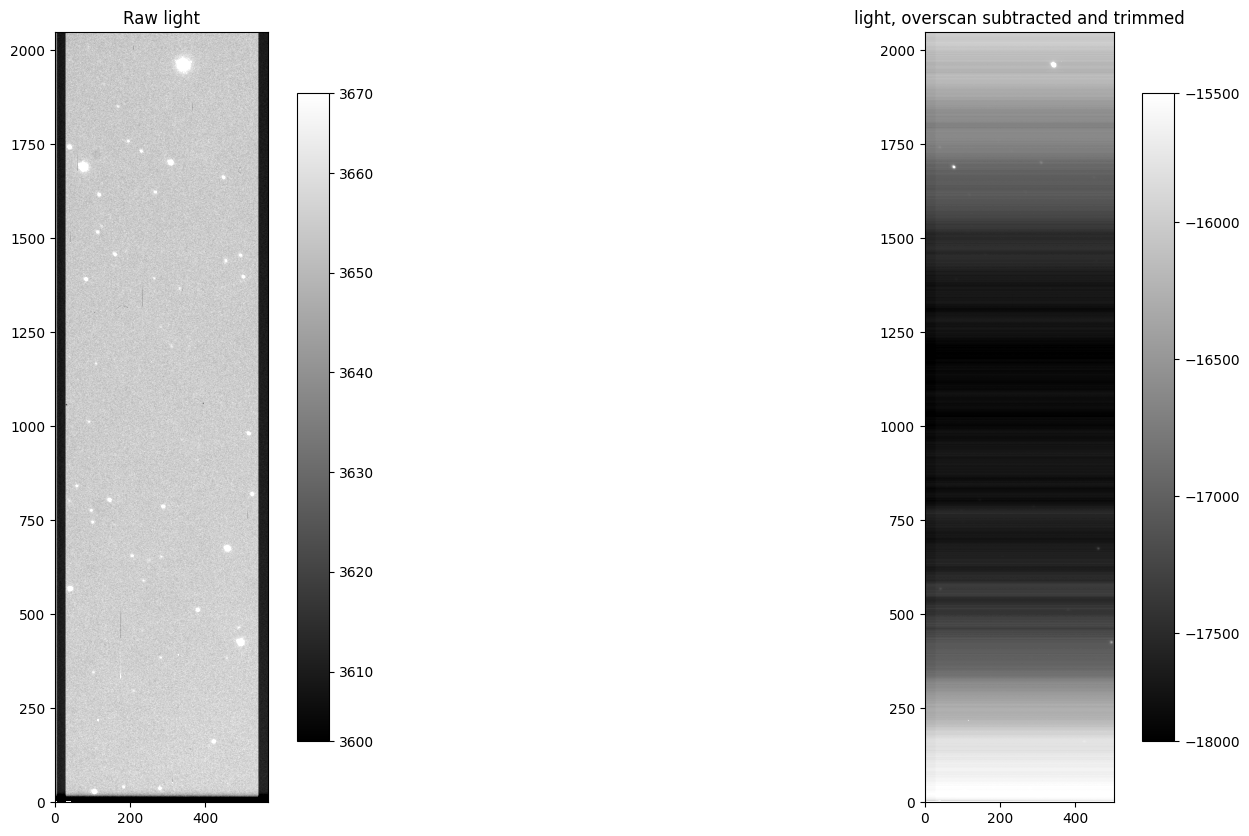

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

show_image(first_light.data, cmap='gray', ax=ax1, fig=fig)
ax1.set_title('Raw light')
show_image(trimmed.data, cmap='gray', ax=ax2, fig=fig)
ax2.set_title('light, overscan subtracted and trimmed')

In [22]:
print(trimmed.shape)


(2048, 503)


In [ ]:
# Second: for performing overscan and trim on all files in a directory

In [36]:
# Input and output paths
input_path = Path('/Users/applestore/exo-observe/Data/GJ-1214b/raw_data')
output_path = Path('/Users/applestore/exo-observe/Data/GJ-1214b/trim')

# Create output directory if it doesn't exist
os.makedirs(output_path, exist_ok=True)

# Find all OBJECT files
files = ccdp.ImageFileCollection(input_path)
raw_files = files.files_filtered(include_path=True, OBSTYPE='OBJECT')

# Process each file
for raw_file in raw_files:
    # Read the image
    image = CCDData.read(raw_file, unit='adu')

    # Overscan subtraction
#    overscan_subtracted = ccdp.subtract_overscan(image, overscan=image[:, 504:], median=True)
    overscan_subtracted = ccdp.subtract_overscan(image, overscan=image[:, 32:-33], median=True)

    # Trimming
    #trimmed = ccdp.trim_image(overscan_subtracted[:, :503])
    trimmed = ccdp.trim_image(overscan_subtracted[:, 32:-33])

    # Create output filename
    output_filename = os.path.basename(raw_file).replace('.fits', '_T.fits')
    output_filepath = os.path.join(output_path, output_filename)

    # Save the trimmed image
    trimmed.write(output_filepath)

    # Optional: Display the image (for debugging)
    #show_image(trimmed) 

INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


...

INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:first HDU with data is extension 1.


INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.
INFO:astropy:first HDU with data is extension 1.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa.
a floating-point value was expected. [astropy.wcs.wcs]
a floating-point value was expected.


INFO: first HDU with data is extension 1. [astropy.nddata.ccddata]
